In [55]:
import os 
from glob import glob
import SimpleITK as sitk
import numpy as np
import datasets.path as path
from segment_anything import sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide
from skimage import transform, segmentation, io
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

In [47]:
# training and testing saving dataset path prefix
prefix = './datasets/RAINE_organ_51'
task = 'MRI_Pancreas'
# label id
# left kidney: 1,
# right kidney: 2,
# pancreas: 3,
# background: 0,
label_id = 3
# image size
image_size = 256
#SAM MODEL TYPE 
sam_model_type = 'vit_b'
# SAM checkpoint
checkpoint = './checkpoints/SAM/sam_vit_b_01ec64.pth'
# device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [63]:
# load data paths
images = sorted(glob(os.path.join(path.RAINE_ORGAN_IMAGES_51, '*.nii.gz')))
gts = sorted(glob(os.path.join(path.RAINE_ORGAN_MANUAL_GTS_51, '*.nii.gz')))
names = [os.path.basename(image).split('/')[-1] for image in images]
# split data into train, test
np.random.seed(2023)
np.random.shuffle(names)
train_names = sorted(names[:int(len(names)*0.8)]) # 40
test_names = sorted(names[int(len(names)*0.8):]) # 11
# prepare the save path
save_path_tr = os.path.join(prefix, task, 'train')
save_path_ts = os.path.join(prefix, task, 'test')
# save data ti train nad test folder
os.makedirs(save_path_tr, exist_ok=True)
os.makedirs(save_path_ts, exist_ok=True)


In [43]:
# preprocess the dataset
def min_max_norm_3dimg(img):
    """Min-max normalization [0, 1] for 3D image
    SAM ask for a uint image, with pixel values in [0, 255]
    Args:
        img: 3D image
    Return:
        img: normalized uint 3D image
    """
    
    img_norm = (img - np.min(img)) / np.clip(img.max() - img.min(), a_min=1e-8, a_max=None) * 255
    img_norm[img==0] = 0
    img_norm = img_norm.astype(np.uint8)
    return img_norm

def sam_preprocess(img, gt, image_size, sam_model, device):
    imgs = []
    gts = []
    img_embeddings = []
    index = img.shape[0]
    for i in range(index):
        gt_slice_i = gt[i,:,:]
        gt_slice_i = transform.resize(gt_slice_i, (image_size, image_size), order=0, preserve_range=True, mode='constant', anti_aliasing=True)
        if np.sum(gt_slice_i)>3:
            img_slice_i = img[i,:,:]
            # resize img_slice_i to 256x256
            img_slice_i = transform.resize(img[i,:,:], (image_size, image_size), order=3, preserve_range=True, mode='constant', anti_aliasing=True)
            # convert to three channels
            img_slice_i = np.uint8(np.repeat(img_slice_i[:,:,None], 3, axis=-1))
            assert len(img_slice_i.shape)==3 and img_slice_i.shape[2]==3, 'image should be 3 channels'
            assert img_slice_i.shape[0]==gt_slice_i.shape[0] and img_slice_i.shape[1]==gt_slice_i.shape[1], 'image and ground truth should have the same size'
            imgs.append(img_slice_i)
            # print('img_slice_i', img_slice_i.shape)
            # assert np.sum(gt_slice_i)>100, 'ground truth should have more than 100 pixels'
            gts.append(gt_slice_i)

            if sam_model is not None:
                sam_transform = ResizeLongestSide(sam_model.image_encoder.img_size)
                resize_img = sam_transform.apply_image(img_slice_i)
                resize_img_tensor = torch.as_tensor(resize_img.transpose(2, 0, 1)).to(device)
                # model input: (1, 3, 1024, 1024)
                input_image = sam_model.preprocess(resize_img_tensor[None,:,:,:]) # (1, 3, 1024, 1024)
                assert input_image.shape == (1, 3, sam_model.image_encoder.img_size, sam_model.image_encoder.img_size), 'input image should be resized to 1024*1024'
                with torch.no_grad():
                    embedding = sam_model.image_encoder(input_image)
                    img_embeddings.append(embedding.cpu().numpy()[0])


    if sam_model is not None:
        return imgs, gts, img_embeddings
    else:
        return imgs, gts



In [23]:
for name in train_names:
    img_path = os.path.join(path.RAINE_ORGAN_IMAGES_51, name)
    print('image_name', img_path)
    gt_path = os.path.join(path.RAINE_ORGAN_MANUAL_GTS_51, name)
    # load image and gt
    img = sitk.ReadImage(img_path)
    img_array = sitk.GetArrayFromImage(img)
    gt = sitk.ReadImage(gt_path)
    gt_array = sitk.GetArrayFromImage(gt)
    gt_array = np.uint8(gt_array==label_id)
    # norlize image
    img_norm = min_max_norm_3dimg(img_array) 
    break

image_name /scratch/itee/uqxye5/segmentation/RAINE/organ/train_51/trainingset_51/sub-10010.FatImaging_W.nii.gz


orignal image intensity range -0.55096966 18.991358
norm image intensity range 0 255


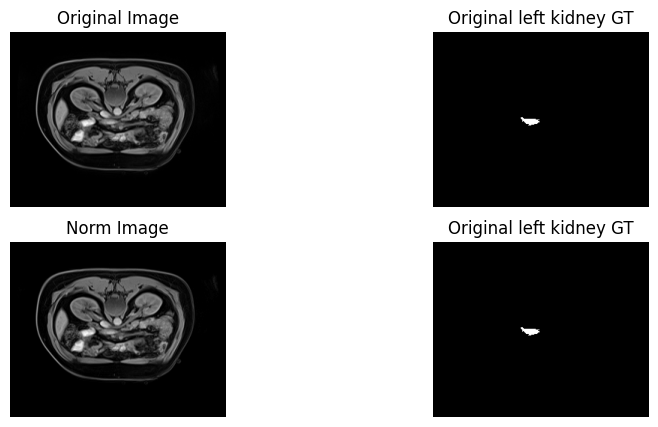

In [57]:
z_index = img_array.shape[0] // 2
fig, ax = plt.subplots(2, 2, figsize=(10, 5))
ax[0,0].imshow(img_array[z_index, :, :], cmap='gray')
ax[0,0].set_title('Original Image')
ax[0,0].axis('off')
ax[0,1].imshow(gt_array[z_index, :, :], cmap='gray')
ax[0,1].set_title('Original left kidney GT')
ax[0,1].axis('off')
print('orignal image intensity range', img_array.min(), img_array.max())

z_index_resized = img_norm.shape[0] // 2
ax[1,0].imshow(img_norm[z_index_resized, :, :], cmap='gray')
ax[1,0].set_title('Norm Image')
ax[1,0].axis('off')
ax[1,1].imshow(gt_array[z_index_resized, :, :], cmap='gray')
ax[1,1].set_title('Original left kidney GT')
ax[1,1].axis('off')
print('norm image intensity range', img_norm.min(), img_norm.max())

plt.show()

In [65]:
# set up the model
sam_model = sam_model_registry[sam_model_type](checkpoint=checkpoint).to(device)

# preprocess the training dataset
# outliers: sub-14870, sub-16880, sub-22770, sub-41810, sub-52220
for name in tqdm(train_names):
    img_path = os.path.join(path.RAINE_ORGAN_IMAGES_51, name)
    gt_path = os.path.join(path.RAINE_ORGAN_MANUAL_GTS_51, name)
    # load image and gt
    img = sitk.ReadImage(img_path)
    img_array = sitk.GetArrayFromImage(img)
    gt = sitk.ReadImage(gt_path)
    gt_array = sitk.GetArrayFromImage(gt)
    gt_array = np.uint8(gt_array==label_id)

    # normalize image
    img_norm = min_max_norm_3dimg(img_array) 

    # preprocess the image and gt for SAM
    imgs, gts, img_embeddings = sam_preprocess(img_norm, gt_array, image_size, sam_model, device)

    # stack the list to array then save to npz file
    if len(imgs)>1:
        imgs = np.stack(imgs, axis=0) # (n, 256, 256, 3)
        gts = np.stack(gts, axis=0) # (n, 256, 256)
        img_embeddings = np.stack(img_embeddings, axis=0) # (n, 1, 256, 64, 64)
        print(name, 'imgs shape', imgs.shape, '\tgts shape', gts.shape)
        np.savez_compressed(os.path.join(save_path_tr, name.split('.nii.gz')[0]+'.npz'), imgs=imgs, gts=gts, img_embeddings=img_embeddings)
        # save an example image for sanity check
        idx = np.random.randint(0, imgs.shape[0])
        img_idx = imgs[idx,:,:,:]
        gt_idx = gts[idx,:,:]
        bd = segmentation.find_boundaries(gt_idx, mode='inner')
        img_idx[bd, :] = [255, 0, 0]
        io.imsave(save_path_tr + '.png', img_idx, check_contrast=False)


  0%|          | 0/40 [00:00<?, ?it/s]

sub-10010.FatImaging_W.nii.gz imgs shape (29, 256, 256, 3) 	gts shape (29, 256, 256)


  2%|▎         | 1/40 [00:17<11:37, 17.88s/it]

sub-10020.FatImaging_W.nii.gz imgs shape (26, 256, 256, 3) 	gts shape (26, 256, 256)


  5%|▌         | 2/40 [00:34<10:40, 16.86s/it]

...

 95%|█████████▌| 38/40 [13:30<00:44, 22.18s/it]

sub-51330.FatImaging_W.nii.gz imgs shape (40, 256, 256, 3) 	gts shape (40, 256, 256)


 98%|█████████▊| 39/40 [13:56<00:23, 23.14s/it]

sub-52220.FatImaging_W.nii.gz imgs shape (39, 256, 256, 3) 	gts shape (39, 256, 256)


100%|██████████| 40/40 [14:20<00:00, 21.52s/it]


In [69]:
sam_model = None
# preprocess the testing dataset
# outliers: sub-12400
for name in tqdm(test_names):
    img_path = os.path.join(path.RAINE_ORGAN_IMAGES_51, name)
    gt_path = os.path.join(path.RAINE_ORGAN_MANUAL_GTS_51, name)
    # load image and gt
    img = sitk.ReadImage(img_path)
    img_array = sitk.GetArrayFromImage(img)
    gt = sitk.ReadImage(gt_path)
    gt_array = sitk.GetArrayFromImage(gt)
    gt_array = np.uint8(gt_array==label_id)

    # normalize image
    img_norm = min_max_norm_3dimg(img_array) 

    # preprocess the image and gt for SAM
    imgs, gts = sam_preprocess(img_norm, gt_array, image_size, sam_model, device)

    # stack the list to array then save to npz file
    if len(imgs)>1:
        imgs = np.stack(imgs, axis=0) # (n, 256, 256, 3)
        gts = np.stack(gts, axis=0) # (n, 256, 256)
        img_embeddings = np.stack(img_embeddings, axis=0) # (n, 1, 256, 64, 64)
        print(name, 'imgs shape', imgs.shape, '\tgts shape', gts.shape)
        np.savez_compressed(os.path.join(save_path_ts, name.split('.nii.gz')[0]+'.npz'), imgs=imgs, gts=gts, img_embeddings=img_embeddings)
        # save an example image for sanity check
        idx = np.random.randint(0, imgs.shape[0])
        img_idx = imgs[idx,:,:,:]
        gt_idx = gts[idx,:,:]
        bd = segmentation.find_boundaries(gt_idx, mode='inner')
        img_idx[bd, :] = [255, 0, 0]
        io.imsave(save_path_ts + '.png', img_idx, check_contrast=False)


  0%|          | 0/11 [00:00<?, ?it/s]

sub-10100.FatImaging_W.nii.gz imgs shape (28, 256, 256, 3) 	gts shape (28, 256, 256)


  9%|▉         | 1/11 [00:07<01:18,  7.87s/it]

sub-10230.FatImaging_W.nii.gz imgs shape (35, 256, 256, 3) 	gts shape (35, 256, 256)


 18%|█▊        | 2/11 [00:15<01:11,  7.97s/it]

...

 82%|████████▏ | 9/11 [01:11<00:16,  8.05s/it]

sub-19830.FatImaging_W.nii.gz imgs shape (34, 256, 256, 3) 	gts shape (34, 256, 256)


 91%|█████████ | 10/11 [01:20<00:08,  8.05s/it]

sub-42510.FatImaging_W.nii.gz imgs shape (30, 256, 256, 3) 	gts shape (30, 256, 256)


100%|██████████| 11/11 [01:27<00:00,  8.00s/it]
